# Exploratory Data Analysis (EDA)

## Business Objective

The objective of this notebook is to analyze the integrated e-commerce datasets and extract actionable business insights.

This analysis focuses on understanding:

- Overall business performance
- Revenue trends over time
- Product and category performance
- Customer and geographic patterns
- Review and satisfaction signals
- User behavior and conversion funnel performance

The goal is not only to create visualizations, but to translate data into business recommendations that could support decision-making by marketing, sales, product, and operations teams.

## Analytical Questions

This notebook answers the following business questions:

1. What are the main business KPIs?
2. How is revenue distributed over time?
3. Which product categories generate the most revenue?
4. Which products are the top revenue drivers?
5. Which cities have the largest customer base?
6. Which customers generate the highest revenue?
7. What does the product rating distribution look like?
8. How do user events move through the funnel?
9. What business recommendations can be made from the analysis?

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

## Set Project Directory

In [2]:
PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

INTEGRATED_DATA_DIR = PROJECT_ROOT / "data" / "integrated"

PROJECT_ROOT

PosixPath('/Users/saadmaher/Desktop/Data Science/Project portfolio/ecommerce-data-analysis')

## Load Integrated Datasets

In [3]:
sales_items = pd.read_csv(INTEGRATED_DATA_DIR / "sales_items_analysis.csv")
reviews_analysis = pd.read_csv(INTEGRATED_DATA_DIR / "reviews_analysis.csv")
events_analysis = pd.read_csv(INTEGRATED_DATA_DIR / "events_analysis.csv")

## Convert Date Columns

In [4]:
sales_items["order_date"] = pd.to_datetime(sales_items["order_date"], errors="coerce")
reviews_analysis["review_date"] = pd.to_datetime(reviews_analysis["review_date"], errors="coerce")
events_analysis["event_timestamp"] = pd.to_datetime(events_analysis["event_timestamp"], errors="coerce")

## Dataset Overview

In [5]:
overview = pd.DataFrame({
    "dataset": ["sales_items", "reviews_analysis", "events_analysis"],
    "rows": [len(sales_items), len(reviews_analysis), len(events_analysis)],
    "columns": [sales_items.shape[1], reviews_analysis.shape[1], events_analysis.shape[1]]
})

overview

,dataset,rows,columns
0,sales_items,43525,21
1,reviews_analysis,15000,17
2,events_analysis,80000,15


# 1. Executive KPI Overview

## Business Question

What is the overall performance of the e-commerce business?

The first step in exploratory analysis is to calculate high-level KPIs that summarize business performance.

In [6]:
total_revenue = sales_items["item_revenue"].sum()
total_orders = sales_items["order_id"].nunique()
total_customers = sales_items["user_id"].nunique()
total_products_sold = sales_items["quantity"].sum()
average_order_value = total_revenue / total_orders

kpi_summary = pd.DataFrame({
    "metric": [
        "Total Revenue",
        "Total Orders",
        "Unique Customers",
        "Total Products Sold",
        "Average Order Value"
    ],
    "value": [
        round(total_revenue, 2),
        total_orders,
        total_customers,
        total_products_sold,
        round(average_order_value, 2)
    ]
})

kpi_summary

,metric,value
0,Total Revenue,11192948.13
1,Total Orders,20000.00
2,Unique Customers,8635.00
3,Total Products Sold,59037.00
4,Average Order Value,559.65


## Interpretation

These KPIs provide a high-level snapshot of the business. Total revenue and order volume indicate commercial activity, while average order value helps measure how much customers spend per order on average.

These metrics will later become the foundation of the Power BI dashboard.

# 2. Monthly Revenue Trend

## Business Question

How does revenue change over time?

Revenue trends help identify seasonality, growth patterns, and potential periods of high or low demand.

In [7]:
monthly_revenue = (
    sales_items
    .dropna(subset=["order_date"])
    .assign(order_month=lambda df: df["order_date"].dt.to_period("M").astype(str))
    .groupby("order_month", as_index=False)["item_revenue"]
    .sum()
)

monthly_revenue.head()

,order_month,item_revenue
0,2024-01,506073.39
1,2024-02,479706.95
2,2024-03,507212.00
3,2024-04,503061.78
4,2024-05,505621.53


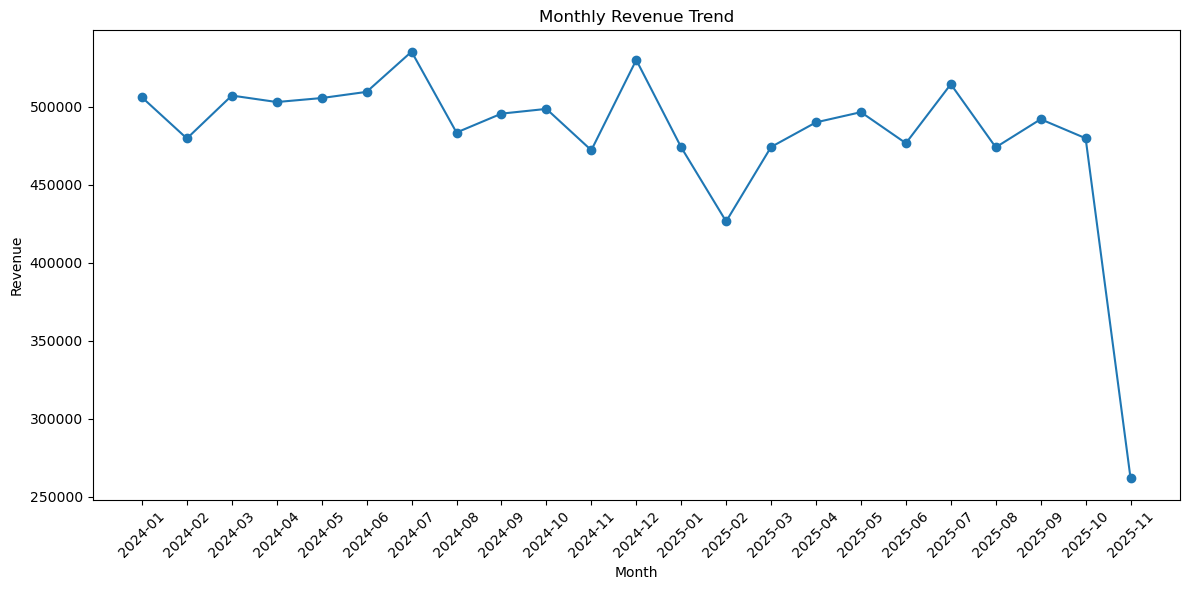

In [8]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_revenue["order_month"], monthly_revenue["item_revenue"], marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Interpretation

The monthly revenue trend shows how business performance evolves over time. Peaks may indicate seasonal demand, promotions, or marketplace events, while declines may suggest periods that require further investigation.

This chart is useful for management because it quickly shows whether revenue is stable, increasing, or volatile.

# 3. Revenue by Product Category

## Business Question

Which product categories generate the most revenue?

Category-level analysis helps identify the strongest business segments and informs merchandising, inventory, and marketing decisions.

In [9]:
category_revenue = (
    sales_items
    .groupby("category", as_index=False)["item_revenue"]
    .sum()
    .sort_values(by="item_revenue", ascending=False)
)

category_revenue

,category,item_revenue
4,Electronics,4468427.83
0,Automotive,2282665.16
6,Home & Kitchen,1029857.45
9,Sports,876137.95
3,Clothing,667071.08
1,Beauty,500591.37
10,Toys,353871.78
8,Pet Supplies,325088.75
2,Books,242542.36
5,Groceries,81164.83


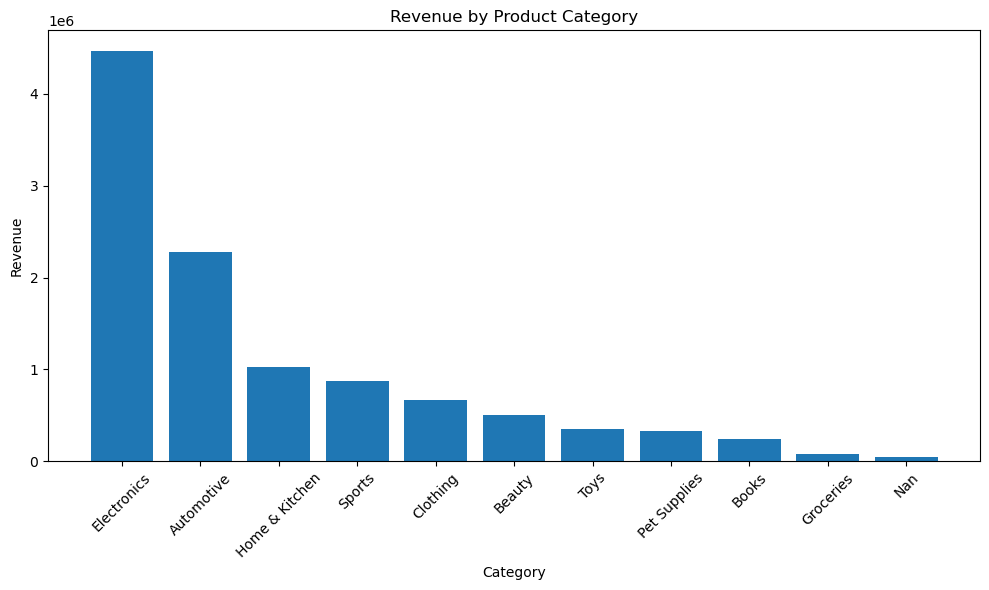

In [10]:
plt.figure(figsize=(10, 6))
plt.bar(category_revenue["category"], category_revenue["item_revenue"])
plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Interpretation

The highest-revenue categories represent the strongest commercial segments. These categories may deserve additional marketing investment, inventory prioritization, or deeper product-level analysis.

Lower-performing categories should not automatically be considered weak; they may have lower inventory, lower prices, or serve niche customer needs.

# 4. Top 10 Products by Revenue

## Business Question

Which products are the strongest revenue drivers?

Product-level revenue analysis helps identify the items that contribute most to total sales.

In [11]:
top_products = (
    sales_items
    .groupby(["product_id", "product_name", "category"], as_index=False)["item_revenue"]
    .sum()
    .sort_values(by="item_revenue", ascending=False)
    .head(10)
)

top_products

,product_id,product_name,category,item_revenue
1439,P001527,Willow Result,Electronics,67168.86
967,P001024,Astra Pull,Electronics,60791.38
20,P000021,Willow Special,Electronics,58487.88
1817,P001925,Willow Hospital,Automotive,53630.40
991,P001049,Zenith Their,Electronics,52799.34
438,P000461,Nimbus Family,Electronics,52710.85
861,P000910,Orion Group,Electronics,51432.70
189,P000198,Orion Face,Electronics,51399.94
697,P000731,Pulse Treat,Electronics,50693.22
132,P000136,Zenith Phone,Electronics,49909.54


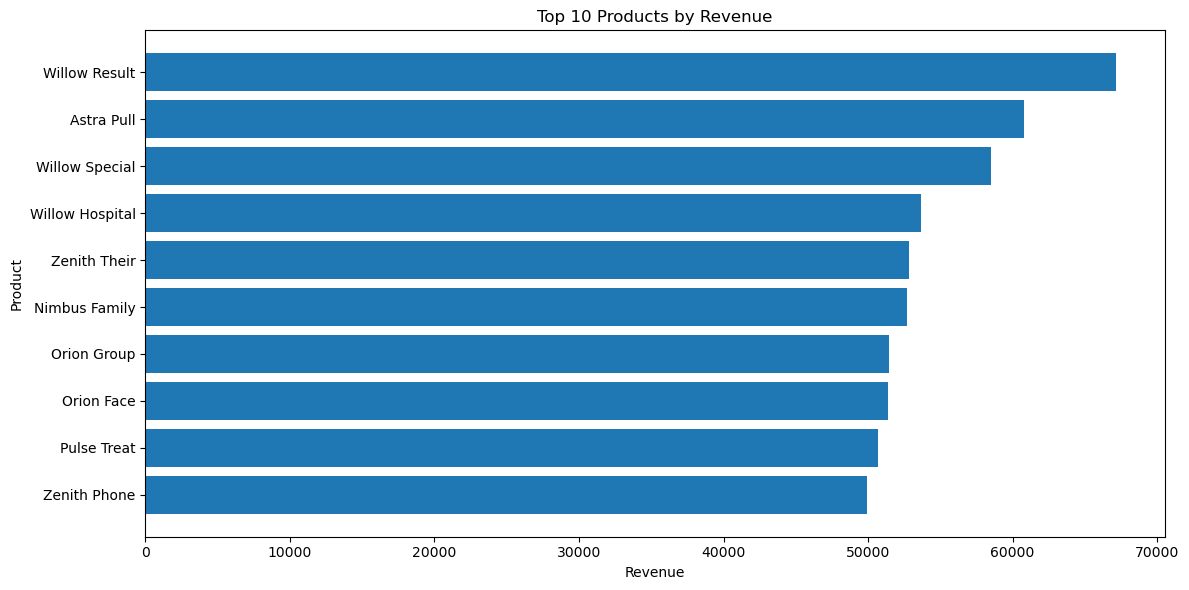

In [12]:
plt.figure(figsize=(12, 6))
plt.barh(top_products["product_name"], top_products["item_revenue"])
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Interpretation

The top revenue-generating products are key business assets. These products may be strong candidates for promotional campaigns, homepage placement, bundle offers, or inventory prioritization.

Further analysis could compare revenue performance with ratings, reviews, and event engagement.

# 5. Customer Distribution by City

## Business Question

Which cities contain the largest customer base?

Geographic customer analysis helps identify markets with strong customer presence and potential marketing opportunities.

In [13]:
top_cities = (
    sales_items
    .dropna(subset=["city"])
    .groupby("city", as_index=False)["user_id"]
    .nunique()
    .rename(columns={"user_id": "unique_customers"})
    .sort_values(by="unique_customers", ascending=False)
    .head(10)
)

top_cities

,city,unique_customers
3186,Nan,36
6367,West Michelle,10
6246,West Jennifer,9
4008,North Michael,9
6353,West Michael,9
2432,Lake John,8
3053,Michaelmouth,7
3566,New Robert,7
1007,East David,7
1996,Johnsonmouth,7


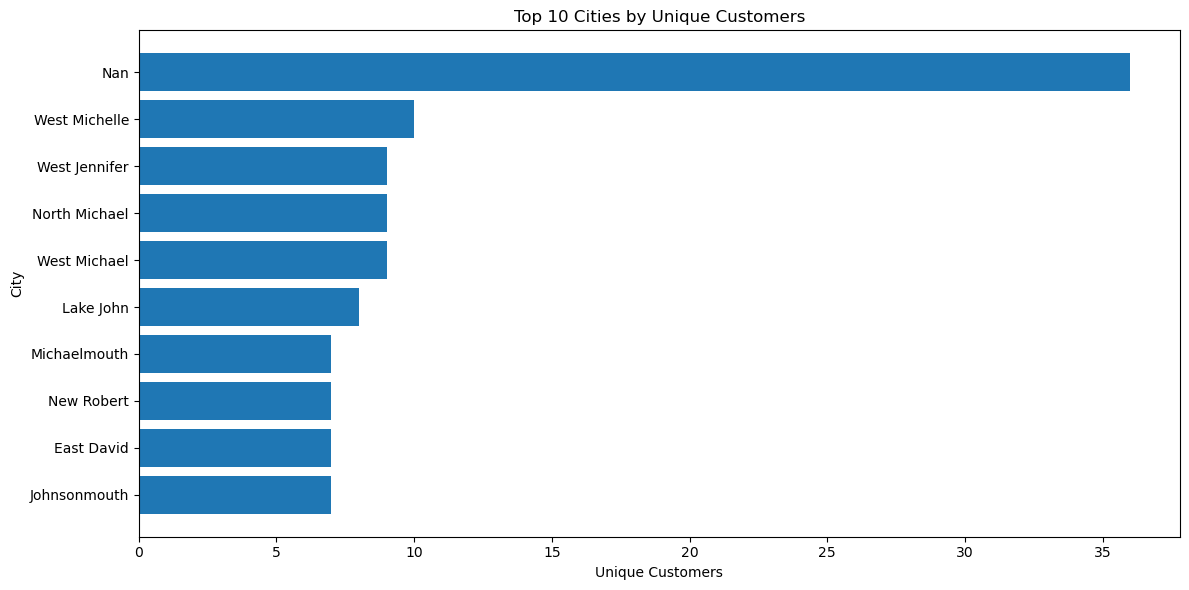

In [14]:
plt.figure(figsize=(12, 6))
plt.barh(top_cities["city"], top_cities["unique_customers"])
plt.title("Top 10 Cities by Unique Customers")
plt.xlabel("Unique Customers")
plt.ylabel("City")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Interpretation

Cities with higher customer counts represent stronger market presence. These locations may be good candidates for targeted marketing, localized campaigns, or logistics optimization.

However, customer count alone does not measure profitability. Revenue by city should also be analyzed.

# 6. Top Customers by Revenue

## Business Question

Who are the highest-value customers?

Customer-level revenue analysis helps identify high-value customers and supports segmentation strategies.

In [15]:
top_customers = (
    sales_items
    .groupby(["user_id", "name", "city"], as_index=False)["item_revenue"]
    .sum()
    .sort_values(by="item_revenue", ascending=False)
    .head(10)
)

top_customers

,user_id,name,city,item_revenue
8272,U009931,Meagan Case,Lake Alyssamouth,13288.88
5194,U006233,Willie Esparza,Tylerland,11234.22
5387,U006469,Audrey Ware,South Robertstad,10953.18
6973,U008370,Brittany Carrillo,Bryanport,10129.48
8251,U009903,Jessica Russell,Nolanborough,10118.31
5,U000006,Michael Santiago,East Steven,9952.28
4103,U004906,Brenda Winters,East Emilyview,9538.69
5192,U006231,Jerome Warner,Port Katherineview,9486.29
6599,U007930,Robert Jennings,Port James,8947.98
4395,U005279,Joseph Houston,Luistown,8843.01


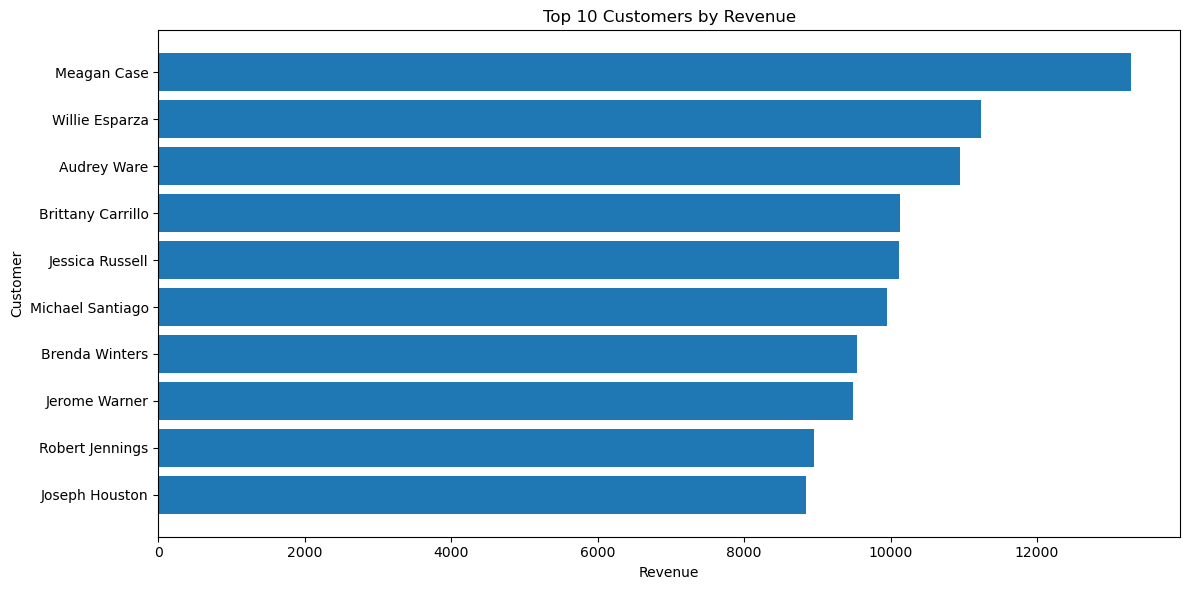

In [16]:
plt.figure(figsize=(12, 6))
plt.barh(top_customers["name"], top_customers["item_revenue"])
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Interpretation

High-value customers contribute disproportionately to revenue. These customers may be valuable targets for loyalty programs, personalized offers, or retention strategies.

This analysis can later be expanded into RFM segmentation.

# 7. Product Rating Distribution

## Business Question

How are products rated by customers?

Ratings provide a high-level view of product satisfaction and perceived quality.

In [17]:
rating_distribution = (
    reviews_analysis
    .dropna(subset=["rating_x"])
    .groupby("rating_x", as_index=False)
    .size()
    .rename(
        columns={
            "rating_x": "rating",
            "size": "review_count"
        }
    )
)

rating_distribution

,rating,review_count
0,1.0,576
1,2.0,1974
2,3.0,4083
3,4.0,4395
4,5.0,3238


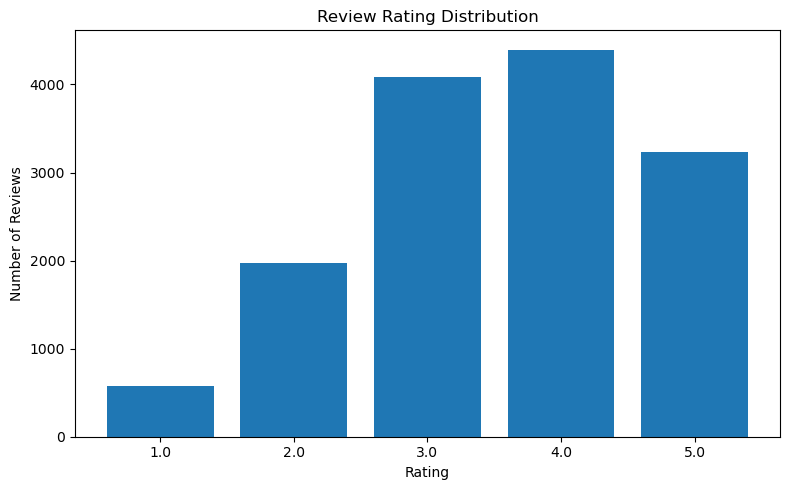

In [18]:
plt.figure(figsize=(8, 5))
plt.bar(rating_distribution["rating"].astype(str), rating_distribution["review_count"])
plt.title("Review Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

## Interpretation

The rating distribution helps identify whether customer feedback is generally positive, negative, or mixed. A concentration of low ratings may indicate product quality issues, while a concentration of high ratings may suggest strong customer satisfaction.

This insight is useful for product teams and customer experience teams.

# 8. Revenue vs Product Rating

## Business Question

Do higher-rated products generate more revenue?

This analysis compares product revenue with product ratings to explore whether customer satisfaction aligns with commercial performance.

In [19]:
product_rating_revenue = (
    sales_items
    .groupby(["product_id", "product_name"], as_index=False)
    .agg(
        total_revenue=("item_revenue", "sum"),
        product_rating=("rating", "mean")
    )
    .dropna(subset=["product_rating", "total_revenue"])
)

product_rating_revenue.head()

,product_id,product_name,total_revenue,product_rating
0,P000001,Astra Be,3473.58,4.08
1,P000002,NeoTech Someone,836.94,3.87
2,P000003,Acme Discuss,8226.47,3.46
3,P000004,Nimbus South,8662.56,4.14
4,P000005,Astra Capital,6930.00,3.97


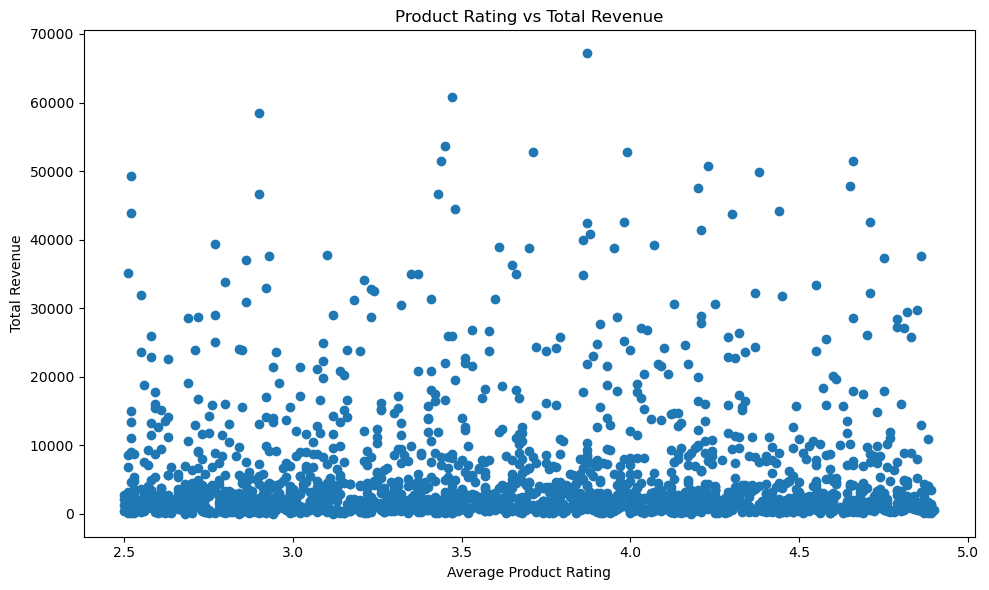

In [20]:
plt.figure(figsize=(10, 6))
plt.scatter(product_rating_revenue["product_rating"], product_rating_revenue["total_revenue"])
plt.title("Product Rating vs Total Revenue")
plt.xlabel("Average Product Rating")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

## Interpretation

This chart explores whether higher-rated products also generate higher revenue. A strong relationship would suggest that customer satisfaction may influence sales performance. A weak relationship may indicate that other factors such as price, visibility, brand, or demand are stronger revenue drivers.

This analysis is exploratory and should be interpreted cautiously.

# 9. Event Funnel Analysis

## Business Question

How do users move through the behavioral funnel?

Events such as views, cart additions, wishlist actions, and purchases help evaluate customer intent and conversion behavior.

In [21]:
event_funnel = (
    events_analysis
    .groupby("event_type", as_index=False)
    .size()
    .rename(columns={"size": "event_count"})
    .sort_values(by="event_count", ascending=False)
)

event_funnel

,event_type,event_count
3,View,54389
0,Cart,11682
4,Wishlist,7708
2,Purchase,3862
1,Nan,155


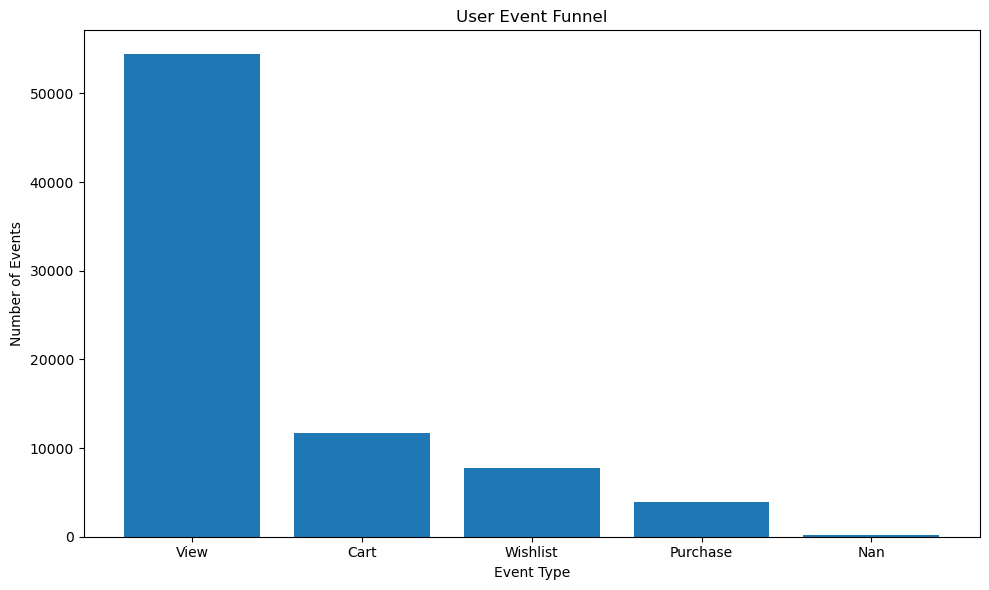

In [22]:
plt.figure(figsize=(10, 6))
plt.bar(event_funnel["event_type"], event_funnel["event_count"])
plt.title("User Event Funnel")
plt.xlabel("Event Type")
plt.ylabel("Number of Events")
plt.tight_layout()
plt.show()

## Interpretation

The event funnel shows how many user actions occur at each stage of the customer journey. A large number of views compared to purchases may indicate normal browsing behavior, but it may also reveal friction in the conversion process.

This analysis can support marketing, product, and user experience improvements.

# 10. Business Recommendations

Based on the exploratory analysis, the following business recommendations can be considered:

1. **Prioritize high-revenue categories**  
   Categories generating the most revenue should be reviewed for inventory support, promotional opportunities, and marketing investment.

2. **Protect top-performing products**  
   High-revenue products should be monitored closely to avoid stockouts and may be featured in campaigns.

3. **Develop customer retention strategies**  
   High-value customers represent an important revenue segment and may benefit from loyalty programs or personalized offers.

4. **Investigate conversion funnel drop-offs**  
   If views and cart actions significantly exceed purchases, the company should investigate pricing, checkout friction, shipping costs, or product availability.

5. **Combine ratings with sales performance**  
   Products with high revenue but low ratings should be reviewed for quality or expectation issues, while high-rated but low-revenue products may need better promotion.

# Executive Summary

## Objective

The objective of this notebook was to explore integrated e-commerce data and identify business insights related to revenue, products, customers, reviews, and user behavior.

## Key Analyses Completed

This notebook analyzed:

- Executive KPIs
- Monthly revenue trends
- Revenue by product category
- Top products by revenue
- Customer distribution by city
- High-value customers
- Product rating distribution
- Rating versus revenue relationship
- User event funnel

## Business Value

The analysis provides an initial understanding of business performance and identifies opportunities for deeper investigation. These insights can support decisions related to marketing, inventory management, customer retention, product strategy, and dashboard development.

## Next Steps

The next stage of the project is SQL Business Analysis. The integrated datasets and key business questions from this notebook will be translated into SQL queries to demonstrate database querying skills and analytical reasoning.

This EDA notebook will also inform the structure of the Power BI dashboard and executive report.